In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9772\1896390004.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=class_counts, palette="viridis")


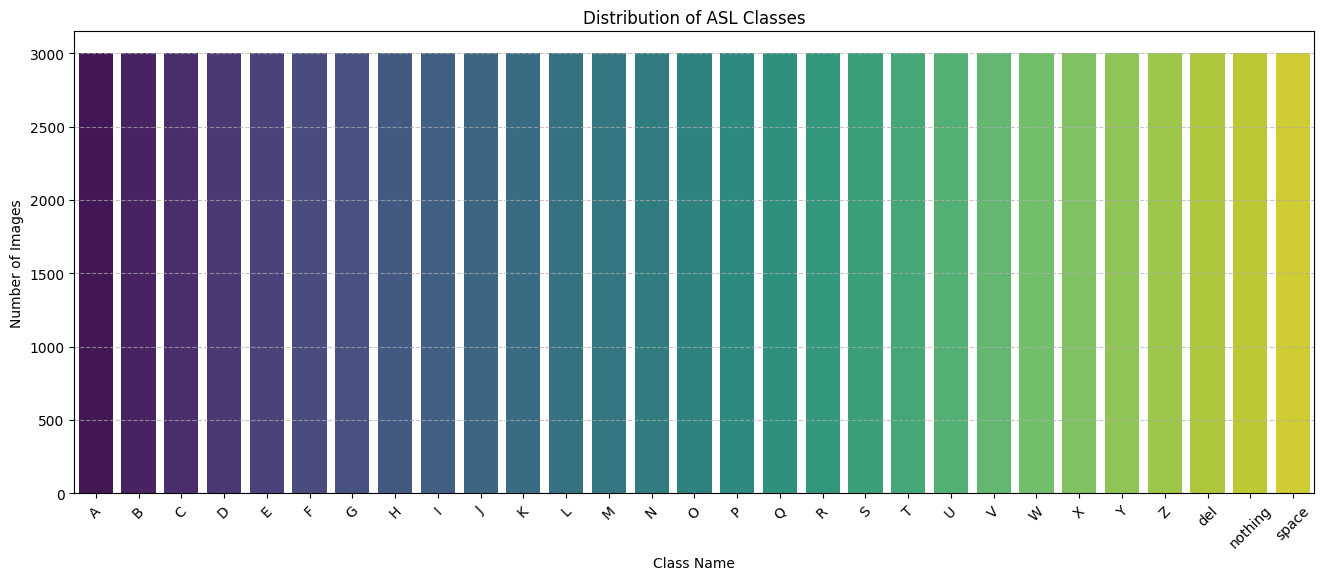

Minimum samples in a class: 3000
Maximum samples in a class: 3000


In [2]:
# Path to the training directory
train_dir = 'alphabet/asl_alphabet_train/'

classes = []
class_counts = []

# Extract class names and the number of images per class
for folder_name in sorted(os.listdir(train_dir)):
    folder_path = os.path.join(train_dir, folder_name)
    if os.path.isdir(folder_path):
        num_images = len(os.listdir(folder_path))
        classes.append(folder_name)
        class_counts.append(num_images)

# Plot the bar chart of class distribution
plt.figure(figsize=(16, 6))
sns.barplot(x=classes, y=class_counts, palette="viridis")
plt.title('Distribution of ASL Classes')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Check data balance
print(f"Minimum samples in a class: {min(class_counts)}")
print(f"Maximum samples in a class: {max(class_counts)}")

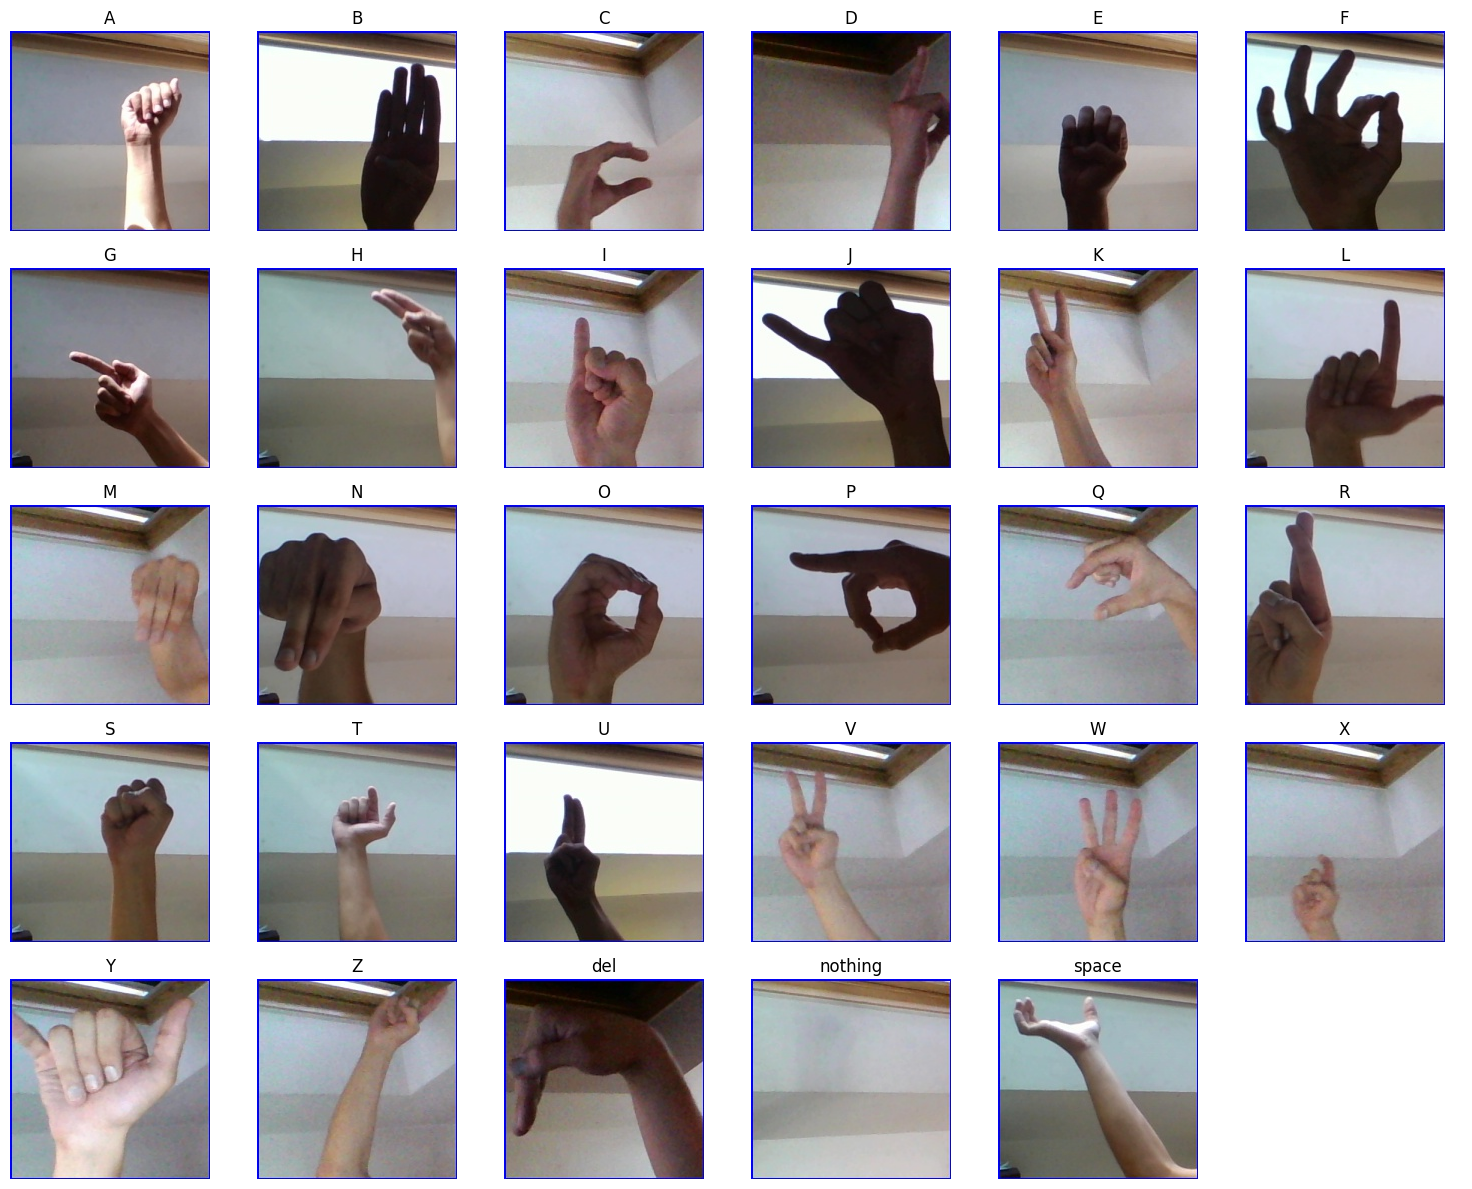

In [3]:
import random

# Set up a 5x6 grid for 29 classes (26 letters + space, del, nothing)
fig, axes = plt.subplots(5, 6, figsize=(15, 12))
axes = axes.flatten()

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)
    
    # Select a random image from the current class
    random_image_name = random.choice(images)
    img_path = os.path.join(class_path, random_image_name)
    
    # Read and convert the image from BGR (OpenCV default) to RGB
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Display the image and set the title
    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis('off')

# Hide the last empty subplot (index 29)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Define target image size
IMAGE_SIZE = (64, 64)

data = []
labels = []

# Map class names to integer labels
class_to_int = {class_name: i for i, class_name in enumerate(classes)}

# Load, resize, and store images and labels
for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        
        # Read and convert image to RGB
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Resize image to 64x64
            img = cv2.resize(img, IMAGE_SIZE)
            
            data.append(img)
            labels.append(class_to_int[class_name])

# Convert lists to NumPy arrays
data = np.array(data, dtype='float32')
labels = np.array(labels)

# Normalize pixel values to the range [0, 1]
data /= 255.0

# Split data: 80% Train, 20% Temp (for Val and Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    data, labels, test_size=0.2, random_state=42, stratify=labels
)

# Split Temp data: 50% Validation, 50% Test (yielding 10% Val and 10% Test overall)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Print the shapes to verify splits
print(f"Train data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")
print(f"Test data shape: {X_test.shape}")

Train data shape: (69600, 64, 64, 3)
Validation data shape: (8700, 64, 64, 3)
Test data shape: (8700, 64, 64, 3)


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Define the CNN architecture
model = Sequential([
    # Convolutional Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    BatchNormalization(), 
    MaxPooling2D((2, 2)),
    
    # Convolutional Block 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Convolutional Block 3
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Fully Connected layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), 
    Dense(len(classes), activation='softmax') # 29 classes
])

# Display model summary
model.summary()

C:\Users\ASUS\Anaconda\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 62, 62, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 29, 29, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 29)                  │           3,741 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 687,837 (2.62 MB)

 Trainable params: 687,389 (2.62 MB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define hyperparameters
learning_rate = 0.001
batch_size = 64
epochs = 20

# Compile the model using Adam optimizer
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Set up callbacks to save the best model and prevent overfitting
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_asl_model.h5', monitor='val_loss', save_best_only=True)
]

# Train the model
history = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

Epoch 1/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.2733 - loss: 2.5196  

1088/1088 ━━━━━━━━━━━━━━━━━━━━ 230s 208ms/step - accuracy: 0.4515 - loss: 1.7735 - val_accuracy: 0.6840 - val_loss: 1.0911
Epoch 2/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.7874 - loss: 0.5920  

1088/1088 ━━━━━━━━━━━━━━━━━━━━ 229s 210ms/step - accuracy: 0.8307 - loss: 0.4780 - val_accuracy: 0.9467 - val_loss: 0.1503
Epoch 3/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 208s 192ms/step - accuracy: 0.9255 - loss: 0.2124 - val_accuracy: 0.9253 - val_loss: 0.2155
Epoch 4/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9471 - loss: 0.1574  

1088/1088 ━━━━━━━━━━━━━━━━━━━━ 188s 173ms/step - accuracy: 0.9504 - loss: 0.1471 - val_accuracy: 0.9582 - val_loss: 0.1260
Epoch 5/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 191s 175ms/step - accuracy: 0.9640 - loss: 0.1098 - val_accuracy: 0.9145 - val_loss: 0.3637
Epoch 6/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9688 - loss: 0.0963  

1088/1088 ━━━━━━━━━━━━━━━━━━━━ 193s 177ms/step - accuracy: 0.9698 - loss: 0.0937 - val_accuracy: 0.9761 - val_loss: 0.0738
Epoch 7/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9755 - loss: 0.0739  

1088/1088 ━━━━━━━━━━━━━━━━━━━━ 191s 176ms/step - accuracy: 0.9769 - loss: 0.0714 - val_accuracy: 0.9940 - val_loss: 0.0155
Epoch 8/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9763 - loss: 0.0762  

1088/1088 ━━━━━━━━━━━━━━━━━━━━ 185s 170ms/step - accuracy: 0.9766 - loss: 0.0753 - val_accuracy: 0.9946 - val_loss: 0.0142
Epoch 9/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 186s 171ms/step - accuracy: 0.9814 - loss: 0.0609 - val_accuracy: 0.9775 - val_loss: 0.0936
Epoch 10/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9850 - loss: 0.0498  

1088/1088 ━━━━━━━━━━━━━━━━━━━━ 188s 173ms/step - accuracy: 0.9840 - loss: 0.0539 - val_accuracy: 0.9978 - val_loss: 0.0059
Epoch 11/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 241s 222ms/step - accuracy: 0.9851 - loss: 0.0495 - val_accuracy: 0.9826 - val_loss: 0.1268
Epoch 12/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 194s 178ms/step - accuracy: 0.9850 - loss: 0.0528 - val_accuracy: 0.9614 - val_loss: 0.2018
Epoch 13/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 199s 183ms/step - accuracy: 0.9882 - loss: 0.0406 - val_accuracy: 0.9509 - val_loss: 0.2367


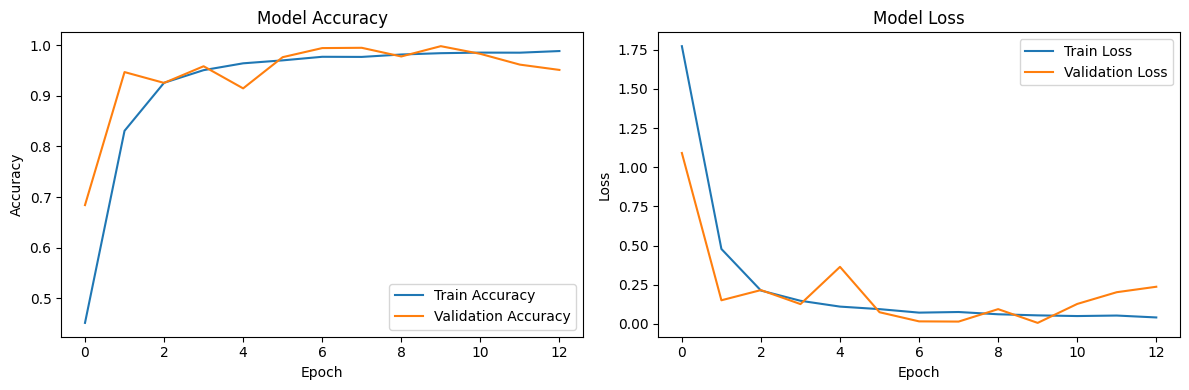

Test Accuracy: 99.82%
272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step


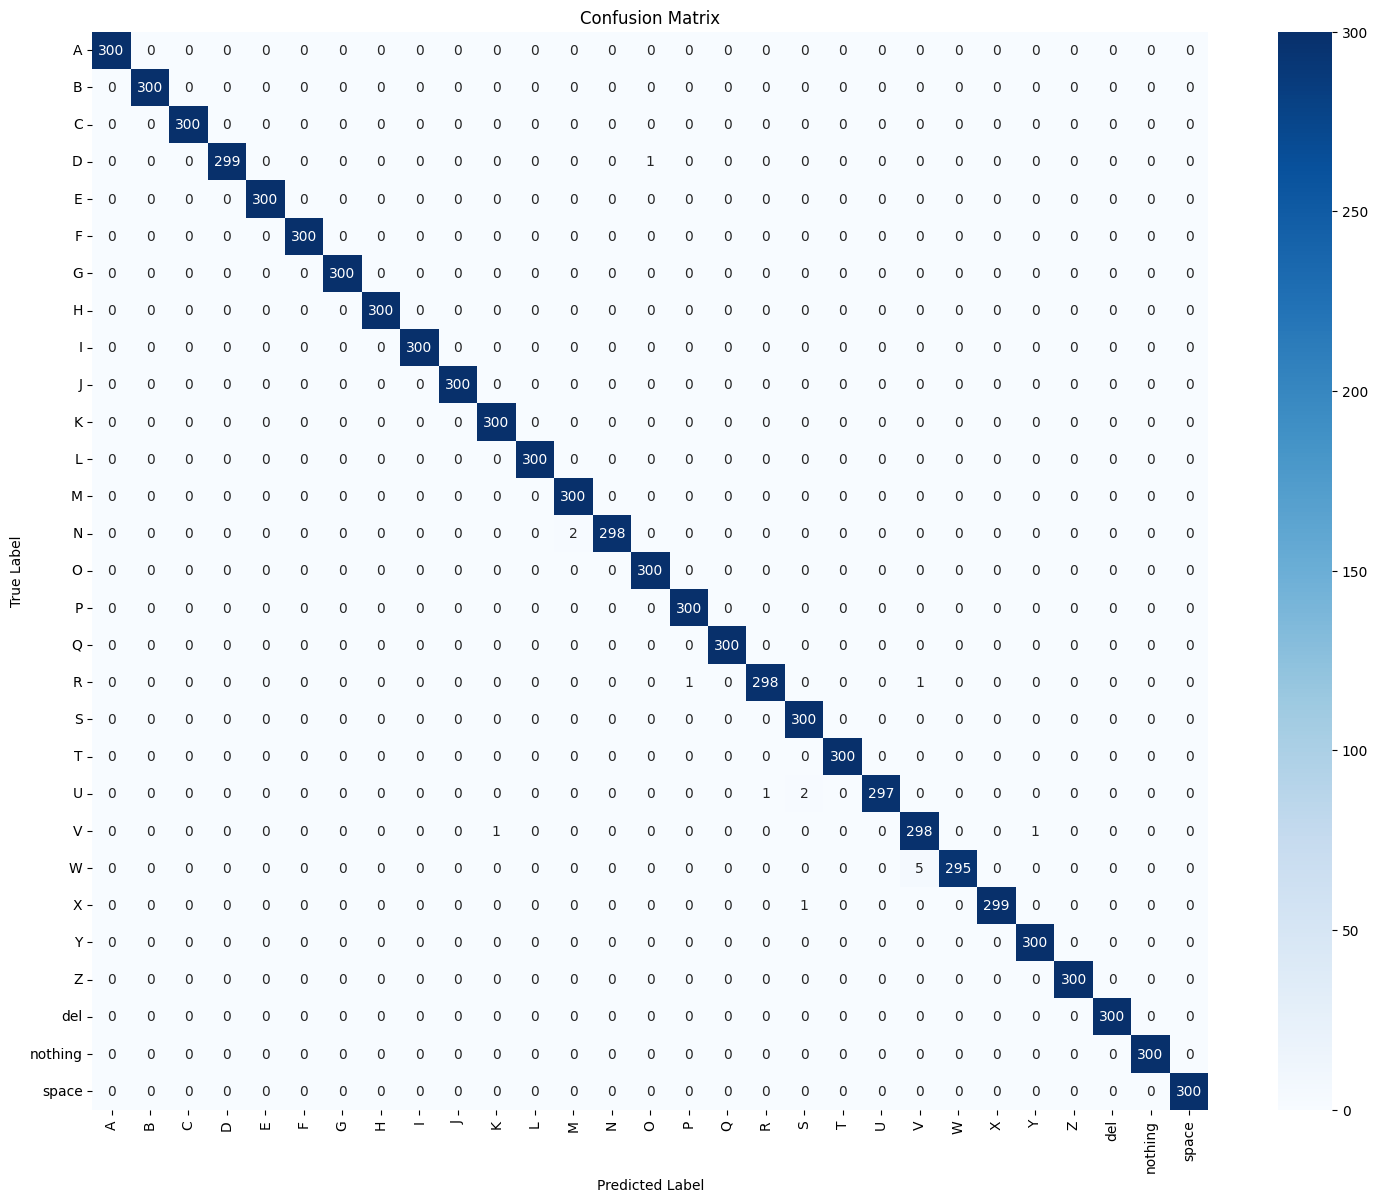

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Plot Training and Validation Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate the model on the Test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Generate predictions for the Test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(18, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()